https://github.com/FabricioArendTorres/FlowConductor/tree/main

In [1]:
%load_ext autoreload
%autoreload 2

import h5py, os
import numpy as np

from msfm.utils import files, parameters

from msi.flow_conductor import architecture
from msi.flow_conductor.likelihood_flow import LikelihoodFlow, LikelihoodFlowEnsemble
from msi.utils import input_output, preprocessing


# load network predictions

# v16

In [2]:
msfm_conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v16/default.yaml")
base_dir = "/pscratch/sd/a/athomsen/deep_lss/v16/default/maps"

In [3]:
probe = "lensing"
params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]

# https://wandb.ai/eth-cosmo/y3-deep-lss/runs/t0vjmhfd/overview
model_name = "v1"
n_steps = 150_000

# # https://wandb.ai/eth-cosmo/y3-deep-lss/runs/ovcdscmw/overview
# model_name = "v2"
# n_steps = 150_000

In [4]:
# probe = "clustering"
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]

# # https://wandb.ai/eth-cosmo/y3-deep-lss/runs/5kxseop3/overview
# model_name = "v1"
# n_steps = 80_000

# # # https://wandb.ai/eth-cosmo/y3-deep-lss/runs/x183fp3k/overview
# # model_name = "v2"
# # n_steps = 80_000

In [5]:
# probe = "combined"
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]


# data

In [6]:
pred_dir = os.path.join(base_dir, probe, model_name)
pred_file = os.path.join(pred_dir, f"preds_{n_steps}.h5")

grid_preds, grid_cosmos, obs_pred_dict, obs_cosmo_dict = input_output.load_network_preds_simple(pred_file)


26-03-26 02:24:15 input_output INF   Loading predictions from /pscratch/sd/a/athomsen/deep_lss/v16/default/maps/lensing/v1/preds_150000.h5 
26-03-26 02:24:15 input_output INF   grid_preds.shape = (200000, 12) 
26-03-26 02:24:15 input_output INF   grid_cosmos.shape = (200000, 6) 
26-03-26 02:24:15 input_output INF   DESy3 with shape (12,) 
26-03-26 02:24:15 input_output INF   bench_box_mean with shape (12,) 
26-03-26 02:24:15 input_output INF   bench_box_stack with shape (80, 12) 
26-03-26 02:24:15 input_output INF   bench_fidu_mean with shape (12,) 
26-03-26 02:24:15 input_output INF   bench_fidu_stack with shape (80, 12) 
26-03-26 02:24:15 input_output INF   bench_particle_mean with shape (12,) 
26-03-26 02:24:15 input_output INF   bench_particle_stack with shape (80, 12) 
26-03-26 02:24:15 input_output INF   bench_redshift_mean with shape (12,) 
26-03-26 02:24:15 input_output INF   bench_redshift_stack with shape (80, 12) 
26-03-26 02:24:15 input_output INF   grid_0 with shape (12,) 

# likelihood Flow $p(x|\theta)$

### loading

In [7]:
# flow = LikelihoodFlow.from_checkpoint(
#     out_dir=pred_dir,
#     suffix=f"_{n_steps}",
# )

In [8]:
# flow = LikelihoodFlowEnsemble.from_checkpoint(
#     out_dir=pred_dir,
#     suffix=f"_{n_steps}",
# )

### training

26-03-26 02:24:19 likelihood_b INF   Set up the model directory /pscratch/sd/a/athomsen/deep_lss/v16/default/maps/lensing/v1/likelihood_flow_150000 
26-03-26 02:24:19 likelihood_f INF   Using the default base distribution: 
26-03-26 02:24:19 likelihood_f INF   <class 'enflows.distributions.normal.StandardNormal'> 
26-03-26 02:24:19 likelihood_f INF   Initialized the normalizing flow 
26-03-26 02:24:19 likelihood_f INF   Running on device cuda with default float torch.float32 
26-03-26 02:24:19 likelihood_f INF   Initializing fresh weights 
26-03-26 02:24:19 likelihood_f INF   batch size = 10000 -> 20 steps per epoch for 100 epochs 
26-03-26 02:24:24 likelihood_f INF   Not using a learning rate scheduler 
100%|████████████████████████████|   | 100/100 [04:03<00:00,  2.44s/it]       lr: 1.00E-03, train: 0.86, vali: 1.27:   
26-03-26 02:28:28 likelihood_b WAR   grid_preds_true.shape = (200000, 12), for sobol sequence + latin hypercube sampling 
26-03-26 02:28:28 likelihood_b INF   Selecti

100%|██████████| 100/100 [00:00<00:00, 134.67it/s]


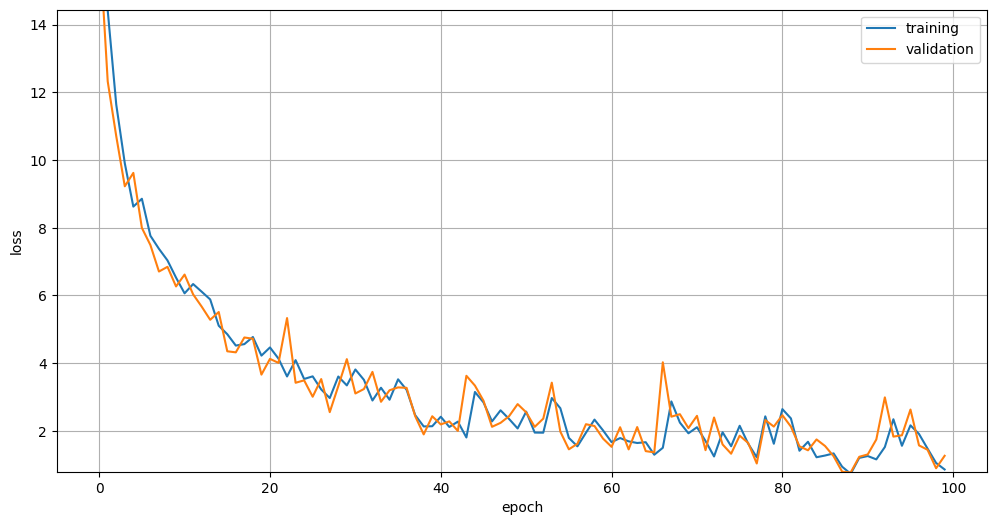

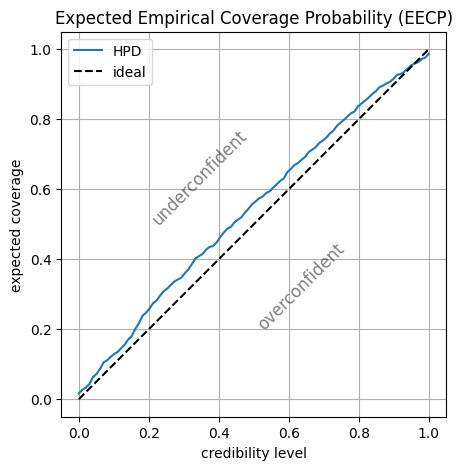

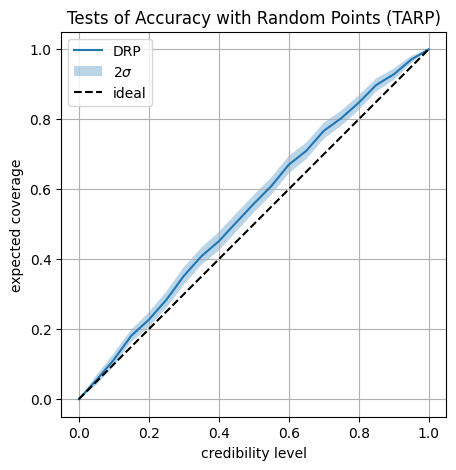

In [9]:
x_dim = grid_preds.shape[-1]
theta_dim = grid_cosmos.shape[-1]

context_embedding_dim = 32

embedding_net = architecture.get_context_embedding_net(
    context_dim=theta_dim,
    context_embedding_dim=context_embedding_dim,
    hidden_dim=64,
)    

transform = architecture.get_sigmoids_transform(
    feature_dim=x_dim,
    context_embedding_dim=context_embedding_dim,
    n_layers=4,
    hidden_dim=256,
    svd_kwargs={},
    sigmoids_kwargs={
        "n_sigmoids": 16,
        "num_blocks": 3,
        "dropout_probability": 0.0,
    }
)

flow = LikelihoodFlow(
# flow = LikelihoodFlowEnsemble(
    params, 
    msfm_conf, 
    feature_dim=grid_preds.shape[-1],
    embedding_net=embedding_net,
    transform=transform,
    out_dir=pred_dir,
    suffix=f"_{n_steps}",
    load_existing=False,
)

history = flow.fit(
    x=grid_preds,
    theta=grid_cosmos,
    n_epochs=100,
    batch_size=10_000,
    scheduler_type="cosine",
    save_model=True,
    run_c2st=True,
)

grid_preds_sample = flow.plot_diagnostics(
    grid_preds_true=grid_preds,
    grid_cosmos=grid_cosmos,
    n_cosmos=1000,
)

# observation

## CosmoGrid

### grid

In [10]:
# obs_dict = {}

# n_examples = 4

# for i_grid in range(n_examples):
#     # unique cosmological parameters
#     i_grid *= msfm_conf["analysis"]["grid"]["n_perms_per_cosmo"] * msfm_conf["analysis"]["n_patches"]
    
#     obs_label = f"grid_{i_grid}"
#     obs_dict[obs_label] = {
#         "pred": obs_pred_dict[obs_label],
#         "cosmo": {str(param): value for param, value in zip(params, obs_cosmo_dict[obs_label])},
#     }


### benchmarks

In [11]:
obs_dict = {}
obs_cosmo = {str(param): value for param, value in zip(params, parameters.get_fiducials(params, msfm_conf))}

obs_labels = ["bench_fidu"]
# obs_labels += ["bench_box", "bench_particle", "bench_redshift"]
# # obs_labels += ["source_clustering_bgs_low", "source_clustering_bgs_high"]
# # obs_labels = ["fidu_bary", "fidu_dmo"]
# # obs_labels += ["ia_shell"]

for obs_label in obs_labels:
    obs_label += "_mean"
    obs_pred = obs_pred_dict[obs_label]
    
    obs_dict[obs_label] = {
        "pred": obs_pred, 
        "cosmo": obs_cosmo,
    }


## DES Y3

In [12]:
# obs_dict = {}

# obs_label = "DESy3"

# obs_dict[obs_label] = {
#     "pred": obs_pred_dict[obs_label],
#     "cosmo": None,
# }

## Buzzard

In [13]:
# obs_labels = []
# # obs_labels += [f"Buzzard_{i}" for i in [0] + list(range(2, 16))]
# obs_labels += ["Buzzard_mean"]
# # obs_labels += ["Buzzard_stack"]

# for obs_label in obs_labels:
#     obs_pred = obs_pred_dict[obs_label]
    
#     obs_dict[obs_label] = {
#         "pred": obs_pred, 
#         "cosmo": obs_cosmo,
#     }

In [14]:
# obs_dict = {}

# # buzzard_indices = list(range(0, 16))
# # buzzard_indices.remove(1)
# buzzard_indices = [0, 2]
# buzzard_stack = []
# for i in buzzard_indices:
#     pred = obs_pred_dict[f"Buzzard_{i}"]
#     buzzard_stack.append(pred)
    
#     # obs_dict[f"Buzzard_{i}"] = {
#     #     "pred": pred,
#     #     "cosmo": buzzard_cosmo,
#     # }

# buzzard_stack = np.stack(buzzard_stack, axis=0)

# obs_dict[f"Buzzard_mean"] = {
#     "pred": np.mean(buzzard_stack, axis=0),
#     "cosmo": buzzard_cosmo,
# }

# obs_dict[f"Buzzard_stack"] = {
#     "pred": np.stack(buzzard_stack, axis=0),
#     "cosmo": buzzard_cosmo,
# }

### MCMC and plotting


Starting with mock observation bench_fidu_mean
26-03-26 02:28:53 likelihood_f INF   Sampling the posterior from a single observation 
26-03-26 02:28:53 likelihood_f WAR   wCDM 
26-03-26 02:28:53      mcmc.py INF   Initial values in prior: 50.5% 
26-03-26 02:28:53      mcmc.py INF   Starting the burn in MCMC chain (1000 steps) 


100%|██████████| 1000/1000 [00:25<00:00, 38.82it/s]

26-03-26 02:29:18      mcmc.py INF   Starting the main MCMC chain (1000 steps) 



100%|██████████| 1000/1000 [00:25<00:00, 38.78it/s]

26-03-26 02:29:44      mcmc.py INF   Saved the MCMC chain to /pscratch/sd/a/athomsen/deep_lss/v16/default/maps/lensing/v1/likelihood_flow_150000/chain_bench_fidu_mean.npy 


...

  0%|          | 0/21 [00:00<?, ?it/s]

/global/homes/a/athomsen/.local/perlmutter/pytorch2.6.0/lib/python3.12/site-packages/trianglechain/make_subplots.py:130: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  axc.plot(


  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

26-03-26 02:29:49  plotting.py INF   Saved the plot to /pscratch/sd/a/athomsen/deep_lss/v16/default/maps/lensing/v1/likelihood_flow_150000/contours_bench_fidu_mean.png 


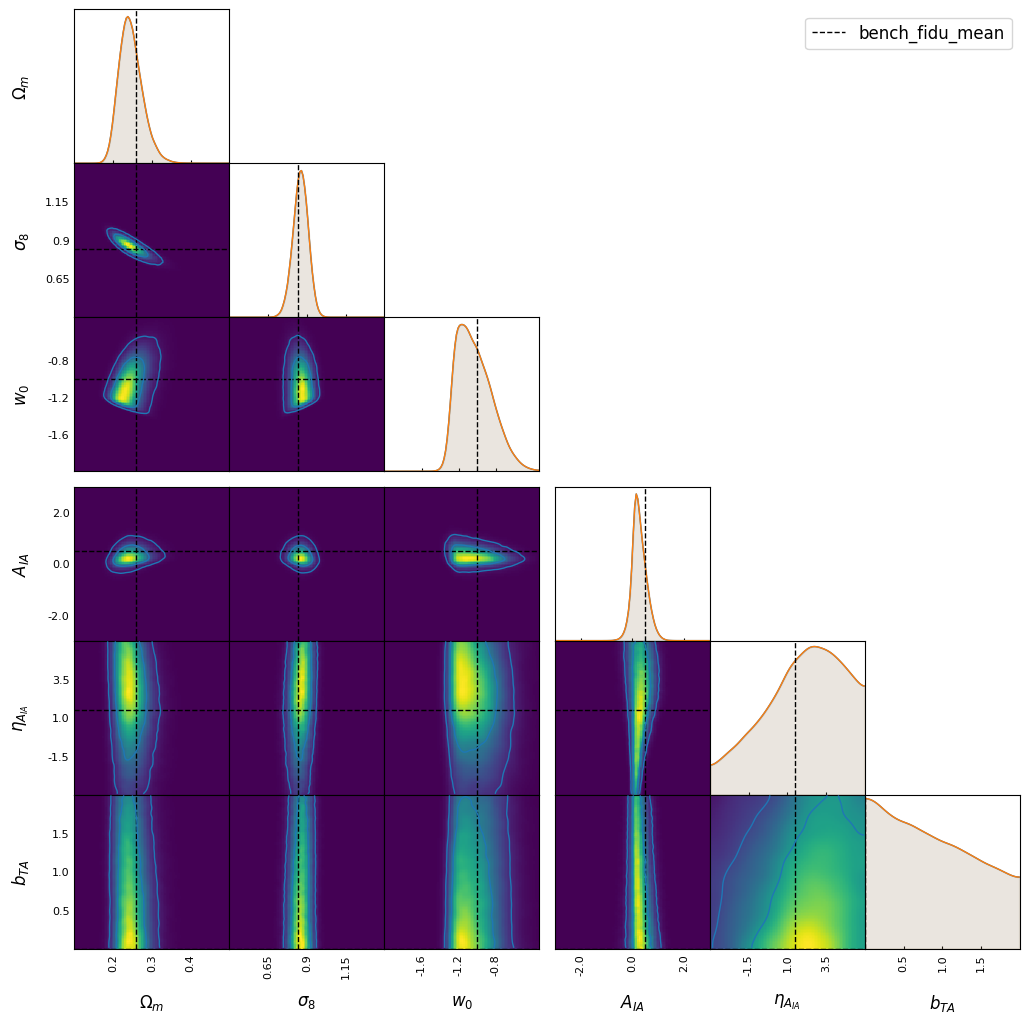

In [15]:
extra_label = ""

for key in obs_dict.keys():
    print(f"\nStarting with mock observation {key}")
    
    posterior_samples = flow.sample_posterior(
        obs_dict[key]["pred"],
        label=key+extra_label,
        n_walkers=1024,
        n_steps=1000,
        n_burnin_steps=1000,
    )

    if not "des" in key.lower():
        flow.plot_contours(
            posterior_samples,
            obs_point=obs_dict[key]["cosmo"],
            obs_label=key,
            label=key+extra_label,
            with_des_chain=False,
            density=True
        )
    